# CSCI 345 — Introduction to Machine Learning

## A Simple First Lab with Penguins

**Name:** ____________________  
**Date:** ____________________  
**Estimated time:** 75–90 minutes

In this lab, you will explore the Palmer Penguins dataset. Each row describes one penguin. The long-term machine-learning goal is to predict a penguin's `species` from physical measurements.

> Each section follows **See it → Try it → Check it**.

## Learning objectives

By the end of the lab, you will be able to:

1. load and inspect a pandas DataFrame;
2. select columns and filter rows;
3. find and handle missing values;
4. summarize and visualize data; and
5. separate input features (`X`) from a prediction target (`y`); and
6. train and evaluate a simple scikit-learn classification model.

## Dataset columns

| Column | Meaning |
|---|---|
| `species` | Adelie, Chinstrap, or Gentoo |
| `island` | Island where the penguin was observed |
| `bill_length_mm` | Bill length in millimeters |
| `bill_depth_mm` | Bill depth in millimeters |
| `flipper_length_mm` | Flipper length in millimeters |
| `body_mass_g` | Body mass in grams |
| `sex` | Recorded sex |

## 0. Setup and load the data

### See it

Seaborn provides the penguins dataset. The first load may require internet access. If your instructor provides `penguins.csv`, the fallback code loads that local file instead.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

local_file = Path("penguins.csv")
if local_file.exists():
    penguins = pd.read_csv(local_file)
else:
    penguins = sns.load_dataset("penguins")

print("Dataset loaded")

Dataset loaded


## 1. First look

### See it

- `head()` previews rows.
- `shape` reports `(rows, columns)`.
- `info()` reports column names, types, and non-missing counts.

In [2]:
display(penguins.head())
print("Shape:", penguins.shape)
penguins.info()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Shape: (344, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


### Try it 1

1. Display the final three rows.
2. Save the number of rows as `n_penguins`.
3. Save the number of columns as `n_columns`.
4. Save the column names as `column_names`.

In [3]:
# Replace each ____
penguins[-3:] # final three rows


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,Male


In [4]:

n_penguins = len(penguins['species'])
n_columns = len(penguins.columns)
column_names = penguins.columns
print(n_penguins, n_columns, column_names)

344 7 Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


In [5]:
# CHECK 1
assert n_penguins == 344
assert n_columns == 7
assert "species" in column_names
assert "body_mass_g" in column_names
print("✓ Check 1 passed")

✓ Check 1 passed


**Explain:** What does one row represent? Which column would be the prediction target?
One row is the data on one penguin. The target column is 'species'.
...

## 2. Select and filter data

### See it

Use one pair of brackets for one column and double brackets for several columns. A comparison inside brackets filters rows.

In [6]:
# Select one column
display(penguins["species"].head())

# Select several columns
small_view = penguins[["species", "island", "body_mass_g"]]
display(small_view.head())

# Filter rows
gentoo = penguins[penguins["species"] == "Gentoo"]
display(gentoo.head())

0    Adelie
1    Adelie
2    Adelie
3    Adelie
4    Adelie
Name: species, dtype: object

,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,3450.0


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
220,Gentoo,Biscoe,46.1,13.2,211.0,4500.0,Female
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
222,Gentoo,Biscoe,48.7,14.1,210.0,4450.0,Female
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,Male


### Try it 2

1. Create `measurements` containing `species`, `bill_length_mm`, `flipper_length_mm`, and `body_mass_g`.
2. Create `heavy_penguins` containing penguins with body mass of at least 5,000 grams.
3. Create `biscoe_females` containing female penguins from Biscoe island. Use `&` and put each condition in parentheses. **Hint:** use `.str.lower() == "female"` so the filter works regardless of capitalization.

In [7]:
measurements = penguins[['species', 'bill_length_mm','flipper_length_mm', 'body_mass_g']]
heavy_penguins = penguins[penguins['body_mass_g'] > 5000]
biscoe_females = penguins[(penguins['sex'].str.lower() == 'female') & (penguins['island'].str.lower() == 'biscoe')]

display(heavy_penguins.head(), biscoe_females)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
221,Gentoo,Biscoe,50.0,16.3,230.0,5700.0,Male
223,Gentoo,Biscoe,50.0,15.2,218.0,5700.0,Male
224,Gentoo,Biscoe,47.6,14.5,215.0,5400.0,Male
227,Gentoo,Biscoe,46.7,15.3,219.0,5200.0,Male
229,Gentoo,Biscoe,46.8,15.4,215.0,5150.0,Male


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
20,Adelie,Biscoe,37.8,18.3,174.0,3400.0,Female
22,Adelie,Biscoe,35.9,19.2,189.0,3800.0,Female
25,Adelie,Biscoe,35.3,18.9,187.0,3800.0,Female
27,Adelie,Biscoe,40.5,17.9,187.0,3200.0,Female
28,Adelie,Biscoe,37.9,18.6,172.0,3150.0,Female
...,...,...,...,...,...,...,...
332,Gentoo,Biscoe,43.5,15.2,213.0,4650.0,Female
334,Gentoo,Biscoe,46.2,14.1,217.0,4375.0,Female
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female


In [8]:
# CHECK 2
assert measurements.shape == (344, 4)
assert heavy_penguins["body_mass_g"].min() >= 5000
assert len(heavy_penguins) > 0
assert len(biscoe_females) > 0
assert biscoe_females["island"].eq("Biscoe").all()
assert biscoe_females["sex"].str.lower().eq("female").all()
print("✓ Check 2 passed")

✓ Check 2 passed


**Explain:** Describe the `biscoe_females` filter in ordinary language.
We are getting a new data frame of only the penguins who are female on Biscoe island.
...

## 3. Missing values

### See it

Real datasets are often incomplete. Count missing values before deciding what to do.

In [9]:
missing_counts = penguins.isna().sum()
display(missing_counts)
print("Total missing cells:", missing_counts.sum())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total missing cells: 19


For this beginner lab, we will remove rows with missing values using `dropna()`. This is simple, but it loses data. In a larger project, we would investigate why values are missing and consider imputation.

In [10]:
penguins_clean = penguins.dropna().copy()
print("Before cleaning:", len(penguins))
print("After cleaning:", len(penguins_clean))
print("Rows removed:", len(penguins) - len(penguins_clean))

Before cleaning: 344
After cleaning: 333
Rows removed: 11


### Try it 3

1. Save the number of rows removed as `rows_removed`.
2. Save the remaining number of missing cells as `missing_after`.
3. Confirm that the original `penguins` DataFrame still contains 344 rows.

In [13]:
rows_removed = len(penguins) - len(penguins_clean)
missing_after = penguins_clean.isna().sum().sum()
original_rows = penguins.shape[0]

In [14]:
# CHECK 3
assert rows_removed == 11
assert missing_after == 0
assert original_rows == 344
assert len(penguins_clean) == 333
print("✓ Check 3 passed")

✓ Check 3 passed


**Explain:** What is one advantage and one disadvantage of dropping incomplete rows?

...

## 4. Summarize the data

### See it

`describe()` summarizes numerical columns. `value_counts()` counts categories. `groupby()` compares groups.

In [ ]:
display(penguins_clean.describe().round(1))
display(penguins_clean["species"].value_counts())

species_mass = penguins_clean.groupby("species")["body_mass_g"].mean().round(1)
display(species_mass)

### Try it 4

1. Save species counts as `species_counts`.
2. Calculate the median body mass as `median_body_mass`.
3. Calculate mean flipper length by species as `mean_flipper_by_species`.
4. Identify which species has the largest mean flipper length.

In [15]:
species_counts = penguins_clean['species'].value_counts
median_body_mass = penguins_clean['body_mass_g'].median()
mean_flipper_by_species = penguins_clean.groupby("species")['flipper_length_mm'].mean().round(1)

display(species_counts)
display(mean_flipper_by_species)

<bound method IndexOpsMixin.value_counts of 0      Adelie
1      Adelie
2      Adelie
4      Adelie
5      Adelie
        ...  
338    Gentoo
340    Gentoo
341    Gentoo
342    Gentoo
343    Gentoo
Name: species, Length: 333, dtype: object>

species
Adelie       190.1
Chinstrap    195.8
Gentoo       217.2
Name: flipper_length_mm, dtype: float64

In [16]:
# CHECK 4
assert species_counts.to_dict() == {"Adelie": 146, "Gentoo": 119, "Chinstrap": 68}
assert median_body_mass == 4050.0
assert mean_flipper_by_species.idxmax() == "Gentoo"
print("✓ Check 4 passed")

AttributeError: 'function' object has no attribute 'to_dict'

**Explain:** Which species is most common after cleaning? Which has the largest mean flipper length? Support both answers with numbers.

...

## 5. Visualize patterns

### See it: one variable

A histogram shows the distribution of a numerical variable. A count plot shows category frequencies.

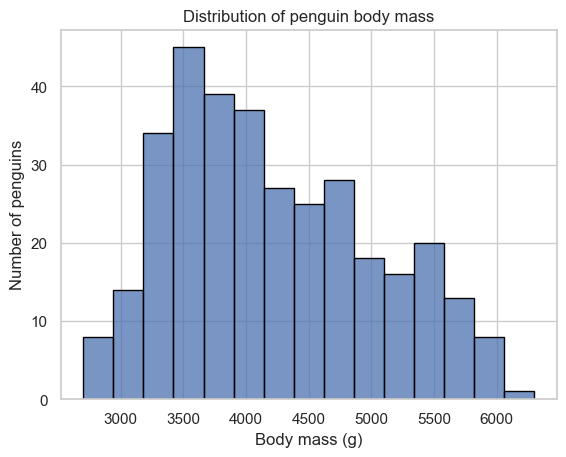

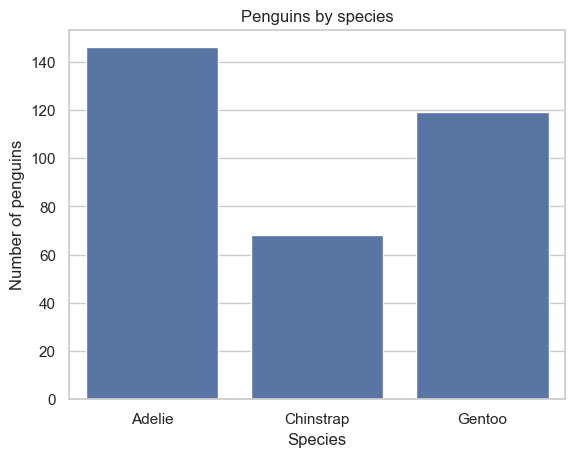

In [17]:
sns.histplot(data=penguins_clean, x="body_mass_g", bins=15, edgecolor="black")
plt.title("Distribution of penguin body mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Number of penguins")
plt.show()

sns.countplot(data=penguins_clean, x="species")
plt.title("Penguins by species")
plt.xlabel("Species")
plt.ylabel("Number of penguins")
plt.show()

### See it: two variables

A scatter plot can reveal a relationship between two numerical measurements.

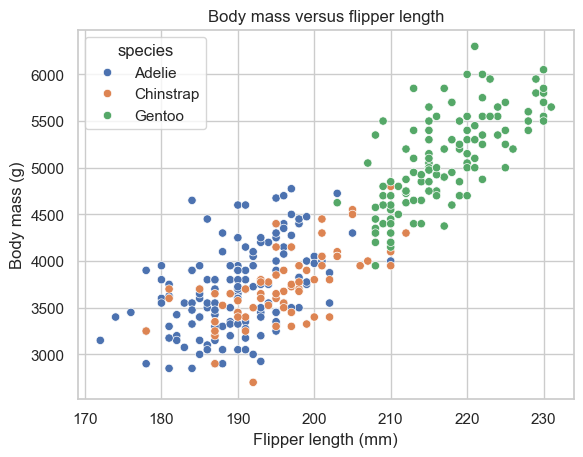

In [18]:
sns.scatterplot(
    data=penguins_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)
plt.title("Body mass versus flipper length")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")
plt.show()

### Try it 5

Create:

1. a histogram of `bill_length_mm` with 15 bins;
2. a scatter plot of `bill_length_mm` against `bill_depth_mm`, colored by species; and
3. descriptive titles and axis labels for both plots.

Then calculate the correlation between bill length and bill depth as `bill_correlation`.

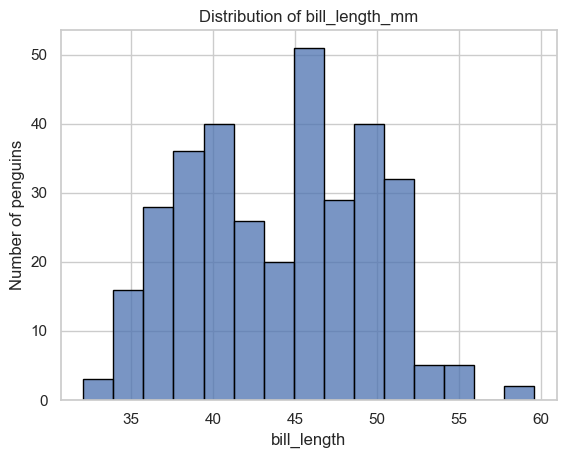

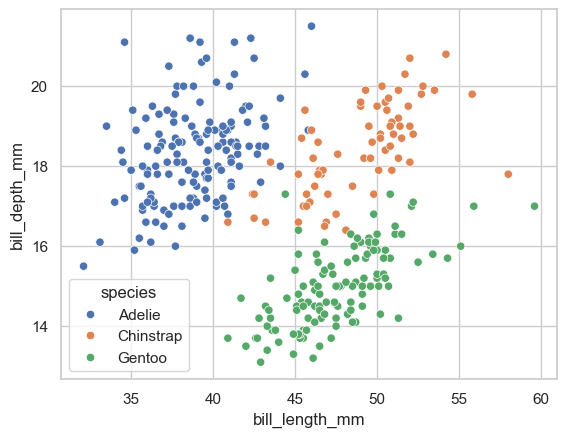

Correlation: -0.23


In [20]:
# Bill-length histogram
sns.histplot(data=penguins_clean, x="bill_length_mm", bins=15, edgecolor="black")
plt.title("Distribution of bill_length_mm")
plt.xlabel("bill_length")
plt.ylabel("Number of penguins")
plt.show()

# Bill-length versus bill-depth scatter plot
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species"
)

plt.show()

bill_correlation = penguins_clean['bill_depth_mm'].corr(penguins_clean['bill_length_mm'])
print("Correlation:", round(bill_correlation, 2))

In [ ]:
# CHECK 5
assert -1 <= bill_correlation <= 1
assert -0.3 < bill_correlation < 0
print("✓ Calculation check passed. Visually confirm both plots have titles and labels.")

**Explain:** What patterns or clusters appear in the scatter plot? Does correlation alone capture everything visible in the species-colored plot?

...

## 6. Prepare data for machine learning

### See it

For supervised learning:

- `X` contains input features used to make predictions.
- `y` contains the target to predict.

Here, the goal is to predict species from four physical measurements.

In [21]:
feature_columns = [
    "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g"
]

X = penguins_clean[feature_columns].copy()
y = penguins_clean["species"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
display(y.head())

X shape: (333, 4)
y shape: (333,)


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


0    Adelie
1    Adelie
2    Adelie
4    Adelie
5    Adelie
Name: species, dtype: object

## 7. Guided supervised learning with scikit-learn

Now use the cleaned penguin measurements to train a simple model that predicts `species`.

### The supervised-learning workflow

1. **Choose features and target:** `X` contains measurements; `y` contains species labels.
2. **Split the data:** training data teaches the model; test data evaluates new predictions.
3. **Build the model:** use logistic regression, a classification algorithm.
4. **Train:** `fit()` learns patterns from the training set.
5. **Predict and evaluate:** compare predictions with the hidden test answers.

> The test set must not be used to train the model. Otherwise, the evaluation would no longer measure performance on unseen data.

### Step 1 — Import the scikit-learn tools

`Pipeline` applies scaling and classification in the correct order. `StandardScaler` places measurements with different units on comparable scales. `LogisticRegression` performs multiclass classification here.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

print("scikit-learn tools imported")

scikit-learn tools imported


### Step 2 — Split the data: See it

We reserve 20% of the rows for testing. `random_state=345` makes the split reproducible. `stratify=y` keeps species proportions similar in both subsets.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=345,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (266, 4)
Testing features: (67, 4)
Training labels: (266,)
Testing labels: (67,)


### Guided Practice 6 — Build and train the model

Complete the pipeline with:

1. a scaler named `"scaler"` using `StandardScaler()`; and
2. a classifier named `"classifier"` using `LogisticRegression(max_iter=1000)`.

Then train it by calling `fit()` with `X_train` and `y_train`.

In [25]:
penguin_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

penguin_model.fit(X_train, y_train)
print("Model trained")

Model trained


In [26]:
# CHECK 6
assert list(penguin_model.named_steps) == ["scaler", "classifier"]
assert hasattr(penguin_model.named_steps["classifier"], "classes_")
assert set(penguin_model.classes_) == {"Adelie", "Chinstrap", "Gentoo"}
assert len(X_train) + len(X_test) == len(X)
print("✓ Check 6 passed")

✓ Check 6 passed


### Step 3 — Predict and evaluate: Guided Practice 7

You have trained **penguin_model** using the training data. Now use it to make predictions on the **unseen test data**.

#### Part A — Make Predictions

Before running the code:

- Which variable should you pass to `predict()`? 
- Why should we not use X_train here?

In [27]:
y_pred = penguin_model.predict(X_test)


#### Part B — Calculate Accuracy

Now we need to compare:

- `y_test` → the **actual species labels**
- `y_pred` → the **model's predicted species labels**

**Accuracy** is the proportion of correct test predictions. It is useful here because the three classes are reasonably represented, but no single metric tells the whole story.

Scikit-learn provides a function called `accuracy_score()` for this comparison.

Think about what the function needs:

```python
accuracy_score(actual_labels, predicted_labels)
```

In our case:

- **actual_labels** → `y_test`
- **predicted_labels** → `y_pred`


##### Think Before You Run

**Predict what will happen:**

1. What do you expect the test accuracy to be? `_____`
2. Will `y_test` and `y_pred` contain the same number of labels? Why?
3. If 90 out of 100 predictions are correct, what should the accuracy be? `_____`

In [29]:
test_accuracy = accuracy_score(y_pred, y_test)

print(f"Test accuracy: {test_accuracy:.3f}")
print("First 10 actual labels:   ", y_test.iloc[:10].tolist())
print("First 10 predicted labels:", y_pred[:10].tolist())

Test accuracy: 1.000
First 10 actual labels:    ['Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie']
First 10 predicted labels: ['Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo', 'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie']


In [30]:
# CHECK 7
assert len(y_pred) == len(y_test)
assert 0 <= test_accuracy <= 1
assert test_accuracy >= 0.85
assert set(y_pred).issubset(set(y.unique()))
print("✓ Check 7 passed")

✓ Check 7 passed


### Step 4 — Examine the errors: See it

A confusion matrix shows actual species in rows and predicted species in columns. Values on the diagonal are correct predictions; off-diagonal values are mistakes.

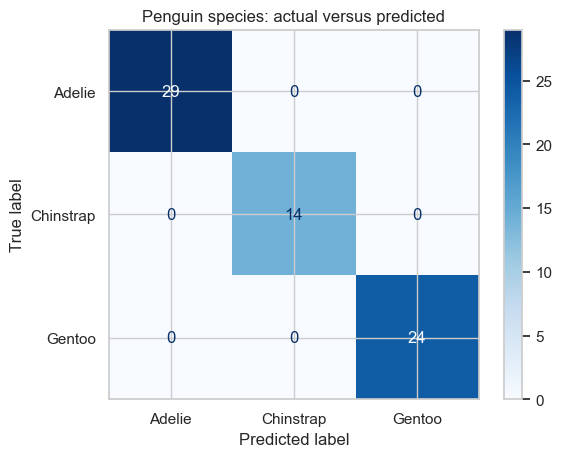

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=penguin_model.classes_,
    cmap="Blues"
)
plt.title("Penguin species: actual versus predicted")
plt.show()

print(classification_report(y_test, y_pred, zero_division=0))

### Interpret the model

Answer in complete sentences:

1. How many penguins were used for training and testing?
2. What percentage of test penguins was classified correctly?
3. Which species, if any, was confused with another species?
4. Why is test accuracy more informative than training accuracy?
5. Why should this result not be interpreted as proof that the model will perform equally well on penguins collected in another location or year?

**Your response:** ...

### Optional experiment

Change only `random_state=345` to another integer and rerun the split, training, and evaluation cells. Did accuracy change? Explain why performance can vary when a finite dataset is split differently.

Restore `random_state=345` before submitting so the checks remain reproducible.

## Final challenge

Without copying a previous filter:

1. create `long_flipper_penguins` containing penguins with flippers of at least 210 mm;
2. keep only `species`, `island`, `flipper_length_mm`, and `body_mass_g`;
3. sort from longest to shortest flipper;
4. calculate `long_flipper_species_counts`; and
5. write three sentences describing the group using at least two numbers and one limitation.

In [ ]:
long_flipper_penguins = ____
long_flipper_penguins = ____
long_flipper_penguins = ____
long_flipper_species_counts = ____

display(long_flipper_penguins.head())
display(long_flipper_species_counts)

In [ ]:
# FINAL CHECK
assert long_flipper_penguins["flipper_length_mm"].min() >= 210
assert long_flipper_penguins.columns.tolist() == [
    "species", "island", "flipper_length_mm", "body_mass_g"
]
assert long_flipper_penguins["flipper_length_mm"].is_monotonic_decreasing
assert long_flipper_species_counts.idxmax() == "Gentoo"
print("✓ Final challenge passed")

In [ ]:
# EXPORT THE TRAINED MODEL FOR THE WEBSITE
import json
from pathlib import Path

scaler = penguin_model.named_steps["scaler"]
classifier = penguin_model.named_steps["classifier"]

website_model = {
    "format": "penguin-logistic-regression-v1",
    "features": feature_columns,
    "classes": classifier.classes_.tolist(),
    "scaler": {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
    },
    "classifier": {
        "coefficients": classifier.coef_.tolist(),
        "intercepts": classifier.intercept_.tolist(),
    },
}

MODEL_FILE = Path("penguin-model.json")
MODEL_FILE.write_text(json.dumps(website_model, indent=2) + "\n")

print(f"Saved website model: {MODEL_FILE.resolve()}")
print(f"Classes: {website_model['classes']}")
print(f"Features: {website_model['features']}")

### Final response

Write your three sentences here.

...

## Submission checklist

Restart the kernel and run all cells before submitting.

- [ ] All seven guided-practice checks and the final check pass.
- [ ] Every blank is replaced with working code.
- [ ] Every graph has a title and labeled axes.
- [ ] Written answers use numerical evidence.
- [ ] The notebook runs top-to-bottom without unintended errors.

## Rubric (15 points)

| Area | Points |
|---|---:|
| Loading, inspection, selection, and filtering | 4 |
| Missing data and summaries | 4 |
| Visualizations and interpretation | 4 |
| Features, supervised model, and final challenge | 3 |

## Exit ticket

1. What does one row in this dataset represent?
2. What is the difference between `X` and `y`?
3. Name one pattern you observed among penguin species.